In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
columns = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'TRA',
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr',
    'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd',
    'PCNfR_dmd', 'W31', 'W32'
]

datasets = ['FD001', 'FD002', 'FD003', 'FD004']
all_train, all_test = [], []
offset = 0

In [3]:
for fd in datasets:
    df_tr = pd.read_csv(f'CMaps/train_{fd}.txt', sep=r'\s+', header=None, names=columns)
    df_te = pd.read_csv(f'CMaps/test_{fd}.txt', sep=r'\s+', header=None, names=columns)
    rul = pd.read_csv(f'CMaps/RUL_{fd}.txt', sep=r'\s+', header=None).values.flatten()
    
    # Apply unique offset
    df_tr['unit_number'] += offset
    df_te['unit_number'] += offset
    
    # Calculate absolute EOL & RUL - Train Set
    eol_tr = df_tr.groupby('unit_number')['time_in_cycles'].transform('max')
    df_tr['EOL'] = eol_tr
    df_tr['RUL'] = eol_tr - df_tr['time_in_cycles']
    
    # Calculate absolute EOL & RUL - Test Set
    eol_te = []
    for eng in df_te['unit_number']:
        cycles_run = len(df_te[df_te['unit_number'] == eng])
        actual_rul = rul[(eng - offset) - 1]
        eol_te.append(cycles_run + actual_rul)
    df_te['EOL'] = eol_te
    df_te['RUL'] = df_te['EOL'] - df_te['time_in_cycles']
    
    all_train.append(df_tr)
    all_test.append(df_te)
    offset += 1000


In [4]:
mega_train_df = pd.concat(all_train, ignore_index=True)
mega_test_df = pd.concat(all_test, ignore_index=True)
print(f"Stitched Training Set: {mega_train_df.shape[0]} rows")
print(f"Stitched Test Set    : {mega_test_df.shape[0]} rows")

Stitched Training Set: 160359 rows
Stitched Test Set    : 104897 rows


In [5]:
# Drop unit and lifecycle helpers
mega_train = mega_train_df.drop(columns=['unit_number', 'EOL'])
mega_test = mega_test_df.drop(columns=['unit_number', 'EOL'])

# Exclude features with zero variance std < 0.01
flatline_cols = mega_train.columns[mega_train.std() < 0.01]
print("Dropped flatline features:", list(flatline_cols))

mega_train = mega_train.drop(columns=flatline_cols)
mega_test = mega_test.drop(columns=flatline_cols, errors='ignore')

Dropped flatline features: ['farB']


In [6]:
X_train_raw = mega_train.drop(columns=['RUL'])
y_train = mega_train['RUL'].clip(upper=125)

X_test_raw = mega_test.drop(columns=['RUL'])
y_test = mega_test['RUL'].clip(upper=125)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

print("Expect features count:", X_train_raw.shape[1])
print("Scaled features sample:")
print(X_train_scaled.head())

Expect features count: 24
Scaled features sample:
   time_in_cycles  setting_1  setting_2       TRA        T2       T24  \
0       -1.464382  -1.041429  -1.115418  0.345955  1.079185  1.046626   
1       -1.452411  -1.041272  -1.115146  0.345955  1.079185  1.054395   
2       -1.440440  -1.041647  -1.113516  0.345955  1.079185  1.059103   
3       -1.428470  -1.041344  -1.114331  0.345955  1.079185  1.059103   
4       -1.416499  -1.041502  -1.114874  0.345955  1.079185  1.059574   

        T30       T50        P2       P15  ...      Ps30       phi       NRf  \
0  1.037990  1.024534  1.107714  1.115018  ...  0.950857  1.113752  0.345200   
1  1.055929  1.043169  1.107714  1.115018  ...  0.956694  1.117528  0.345649   
2  1.023520  1.050946  1.107714  1.115018  ...  0.892485  1.118380  0.345289   
3  0.979517  1.033851  1.107714  1.115018  ...  0.851625  1.121060  0.345739   
4  0.980025  1.065766  1.107714  1.115018  ...  0.895404  1.116979  0.345379   

        NRc       BPR   htBlee

In [7]:
print("🌲 Fitting RandomForest Regressor on Mega-Dataset... (This might take a few seconds)")
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train_scaled, y_train)
print("🎉 Continuous Regressor co-trained successfully!")

🌲 Fitting RandomForest Regressor on Mega-Dataset... (This might take a few seconds)
🎉 Continuous Regressor co-trained successfully!


In [8]:
y_pred = rf_regressor.predict(X_test_scaled)

print("=== PURE REGRESSION EVALUATION ===")
print(f"Test Mean Absolute Error (MAE)  : {mean_absolute_error(y_test, y_pred):.4f} cycles")
print(f"Test Root Mean Squared Error(RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} cycles")
print(f"Test R2 Score                    : {r2_score(y_test, y_pred):.4f}")

=== PURE REGRESSION EVALUATION ===
Test Mean Absolute Error (MAE)  : 9.6784 cycles
Test Root Mean Squared Error(RMSE): 15.4362 cycles
Test R2 Score                    : 0.6698


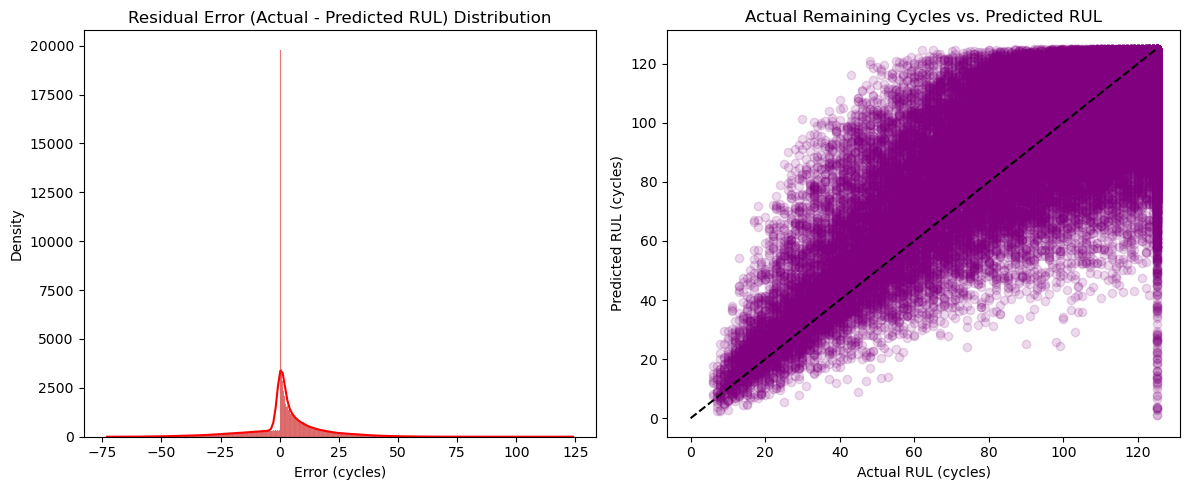

In [9]:
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='red')
plt.title('Residual Error (Actual - Predicted RUL) Distribution')
plt.xlabel('Error (cycles)')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.15, color='purple')
plt.plot([0, 125], [0, 125], '--k')
plt.title('Actual Remaining Cycles vs. Predicted RUL')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')

plt.tight_layout()
plt.show()